# Macro Scenario Data: EDA, Cleaning, and Relationship to Bank Condition

This notebook covers two source files, `macro_scenarios.csv` and `macro_stress_scenarios.csv`.
For each file we first look at the raw data, clean it, then explore it. In the second half of the
notebook we bring in the target label, `bank_condition`, from `bank_stress_simulated_panel.csv` and
check how the macro variables relate to it.

The plan for this notebook:

1. Load and inspect `macro_scenarios.csv`
2. Clean `macro_scenarios.csv`
3. Explore `macro_scenarios.csv`
4. Load, clean and explore `macro_stress_scenarios.csv`
5. Load and clean the target label, `bank_condition`
6. Merge the macro scenario data with the target label
7. Look at how the macro shocks relate to `bank_condition`
8. Do the same, more loosely, for `macro_stress_scenarios.csv`
9. Summary and next steps

A short conclusion is added after each step that produces a result worth remembering, so the
notebook can be read top to bottom as a record of what was found and why each cleaning choice
was made.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

## 1. Load and inspect `macro_scenarios.csv`

The file is loaded as strings first, on purpose. If we let pandas guess the types straight away it will silently turn anything it cannot parse into `NaN`, and we would lose the chance to see what the original bad values actually looked like.

In [2]:
raw_macro = pd.read_csv('macro_scenarios.csv', dtype=str, keep_default_na=False)
print('shape:', raw_macro.shape)
raw_macro.head(10)

shape: (504, 9)


,scenario_id,stress_intensity,scenario_severity,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,inflation_shock_pp,fx_devaluation_pct
0,SCN_0001,0.677,adverse,-7.74,6.76,-0.23,332.0,11.06,26.75
1,SCN_0002,0.89,severe,-9.76,9.41,5.06,460.1,18.19,40.96
2,SCN_0003,0.195,mild,-2.9,2.7,-0.53,71.3,1.72,8.94
3,SCN_0004,0.135,mild,-2.01,1.01,0.35,49.8,7.72,6.2
4,SCN_0005,0.61,adverse,-7.62,6.01,3.95,252.2,5.71,12.31
5,SCN_0006,0.62,adverse,-8.15,6.86,2.96,335.6,10.32,25.6
6,SCN_0007,0.044,baseline,-0.22,0.81,1.85,33.3,2.08,0.0
7,SCN_0008,0.979,severe,-12.45,9.83,1.16,473.5,14.75,37.1
8,SCN_0009,0.193,mild,-1.39,2.57,1.18,130.3,1.57,11.99
9,SCN_0010,0.633,adverse,-7.85,5.43,0.84,285.4,11.92,29.74


In [3]:
raw_macro.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   scenario_id         504 non-null    str  
 1   stress_intensity    504 non-null    str  
 2   scenario_severity   504 non-null    str  
 3   gdp_shock_pp        504 non-null    str  
 4   unemp_shock_pp      504 non-null    str  
 5   rate_shock_pp       504 non-null    str  
 6   credit_spread_bps   504 non-null    str  
 7   inflation_shock_pp  504 non-null    str  
 8   fx_devaluation_pct  504 non-null    str  
dtypes: str(9)
memory usage: 35.6 KB


In [4]:
print('Unique values in scenario_severity, sorted:')
for v in sorted(raw_macro['scenario_severity'].unique(), key=str.lower):
    print(repr(v))

Unique values in scenario_severity, sorted:
''
' mild'
' severe'
'advers'
'adverse'
'ADVERSE'
'Adverse'
'baseline'
'baseline '
'mild'
'MILD'
'Mild'
'mld'
'moderat'
'moderate'
'MODERATE'
'Moderate'
'sever'
'severe'
'SEVERE'
'Severe'
'TBD'
'unknown'


In [5]:
def non_numeric_values(series):
    out = []
    for v in series.unique():
        if v == '':
            continue
        try:
            float(v)
        except ValueError:
            out.append(v)
    return out

for col in ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
            'inflation_shock_pp', 'fx_devaluation_pct', 'stress_intensity']:
    bad = non_numeric_values(raw_macro[col])
    print(f"{col}: {len(bad)} non-numeric value(s), examples: {bad[:5]}")

gdp_shock_pp: 0 non-numeric value(s), examples: []
unemp_shock_pp: 0 non-numeric value(s), examples: []
rate_shock_pp: 2 non-numeric value(s), examples: ['-', 'N/A']
credit_spread_bps: 25 non-numeric value(s), examples: ['264.9 bps', '477.3 bps', '433.4 bps', '191.6 bps', '262.1 bps']
inflation_shock_pp: 0 non-numeric value(s), examples: []
fx_devaluation_pct: 0 non-numeric value(s), examples: []
stress_intensity: 0 non-numeric value(s), examples: []


In [6]:
print('Fully duplicated rows:', raw_macro.duplicated().sum())
print('Duplicated scenario_id values:', raw_macro['scenario_id'].duplicated().sum())

Fully duplicated rows: 4
Duplicated scenario_id values: 4


**Conclusion, step 1.** The raw file has four separate problems:

- `scenario_severity` has mixed casing (`Adverse` vs `ADVERSE`), typos (`sever`, `advers`, `mld`, `moderat`), stray whitespace, and a few rows where the value is blank, `unknown` or `TBD`.
- `credit_spread_bps` is stored as text with a `bps` suffix (`332.0 bps`) instead of a plain number.
- `rate_shock_pp` has some missing values written as blank, `N/A` or `-`.
- There are 4 fully duplicated rows.

Everything else (`gdp_shock_pp`, `unemp_shock_pp`, `inflation_shock_pp`, `fx_devaluation_pct`, `stress_intensity`) is already numeric and clean, so we leave those columns alone.

## 2. Clean `macro_scenarios.csv`

In [7]:
MISSING_TOKENS = {'', 'na', 'n/a', 'n.a.', 'not available', '-', '--', 'missing',
                  'unknown', 'null', 'none', 'tbd', '999', '-999'}

def is_missing_token(value):
    return value.strip().lower() in MISSING_TOKENS

SEVERITY_MAP = {
    'baseline': 'baseline',
    'mild': 'mild', 'mld': 'mild',
    'moderate': 'moderate', 'moderat': 'moderate',
    'adverse': 'adverse', 'advers': 'adverse',
    'severe': 'severe', 'sever': 'severe',
}

def clean_severity(value):
    v = value.strip().lower()
    if is_missing_token(v):
        return np.nan
    return SEVERITY_MAP.get(v, np.nan)

In [8]:
macro = raw_macro.copy()

macro['scenario_severity_clean'] = macro['scenario_severity'].apply(clean_severity)

unmapped = macro.loc[macro['scenario_severity_clean'].isna(), 'scenario_severity'].value_counts()
print('Values that could not be mapped to a known severity:')
print(unmapped)

Values that could not be mapped to a known severity:
scenario_severity
unknown    5
TBD        3
           2
Name: count, dtype: int64


We keep these rows rather than dropping them. The numeric shock columns in those rows are still valid, only the severity label is unreadable, so we mark the label as missing (`NaN`) instead of throwing the whole row away.

In [9]:
def parse_bps(value):
    v = value.strip().lower()
    if is_missing_token(v):
        return np.nan
    v = v.replace('bps', '').strip()
    try:
        return float(v)
    except ValueError:
        return np.nan

def parse_numeric(value):
    v = value.strip().lower()
    if is_missing_token(v):
        return np.nan
    try:
        return float(v)
    except ValueError:
        return np.nan

macro['credit_spread_bps_clean'] = macro['credit_spread_bps'].apply(parse_bps)
macro['rate_shock_pp_clean'] = macro['rate_shock_pp'].apply(parse_numeric)

for col in ['gdp_shock_pp', 'unemp_shock_pp', 'inflation_shock_pp', 'fx_devaluation_pct', 'stress_intensity']:
    macro[col] = pd.to_numeric(macro[col], errors='coerce')

macro = macro.drop(columns=['scenario_severity', 'credit_spread_bps', 'rate_shock_pp'])
macro = macro.rename(columns={
    'scenario_severity_clean': 'scenario_severity',
    'credit_spread_bps_clean': 'credit_spread_bps',
    'rate_shock_pp_clean': 'rate_shock_pp',
})

In [10]:
before = len(macro)
macro = macro.drop_duplicates()
after = len(macro)
print(f'Dropped {before - after} exact duplicate rows, {after} rows left')

Dropped 4 exact duplicate rows, 500 rows left


In [11]:
print('Missing values per column after cleaning:')
print(macro.isna().sum())

Missing values per column after cleaning:
scenario_id            0
stress_intensity       0
gdp_shock_pp           0
unemp_shock_pp         0
inflation_shock_pp     0
fx_devaluation_pct     0
scenario_severity     10
credit_spread_bps      0
rate_shock_pp         20
dtype: int64


**Conclusion, step 2.** After cleaning, `scenario_severity` is down to five clean categories plus a small number of genuinely unrecoverable rows, `credit_spread_bps` and `rate_shock_pp` are proper floats, and the 4 duplicate rows are gone. We did not impute the missing `rate_shock_pp` or `scenario_severity` values here, since dropping or filling them is a modelling decision that depends on what comes next, not a cleaning decision.

## 3. Explore `macro_scenarios.csv`

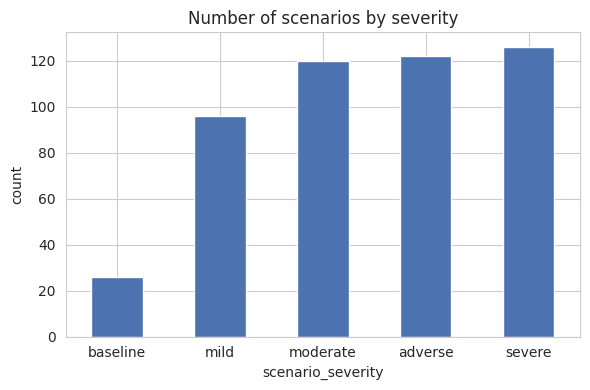

scenario_severity
baseline     26
mild         96
moderate    120
adverse     122
severe      126
Name: count, dtype: int64


In [12]:
order = ['baseline', 'mild', 'moderate', 'adverse', 'severe']
counts = macro['scenario_severity'].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Number of scenarios by severity')
ax.set_xlabel('scenario_severity')
ax.set_ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(counts)

**Conclusion.** Scenarios are reasonably spread across the five severity levels, with no single level dominating the dataset. This matters later, since a very skewed severity mix would make it harder to compare bank_condition rates across levels.

In [13]:
shock_cols = ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
              'inflation_shock_pp', 'fx_devaluation_pct', 'stress_intensity']

macro[shock_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_shock_pp,500.0,-6.077300,3.525997,-12.770,-9.0625,-6.015,-3.04750,1.050
unemp_shock_pp,500.0,5.053460,2.976263,-0.730,2.6025,4.970,7.56750,10.620
rate_shock_pp,480.0,1.152625,1.635553,-1.740,-0.1450,1.020,2.10000,5.390
credit_spread_bps,500.0,252.671800,145.891617,0.000,119.9500,248.950,373.05000,523.200
inflation_shock_pp,500.0,7.747580,4.915360,0.000,3.6400,7.615,11.49000,20.080
fx_devaluation_pct,500.0,17.748800,11.038592,0.000,9.2675,16.400,26.84250,42.610
stress_intensity,500.0,0.506516,0.289857,0.002,0.2545,0.509,0.75675,0.997


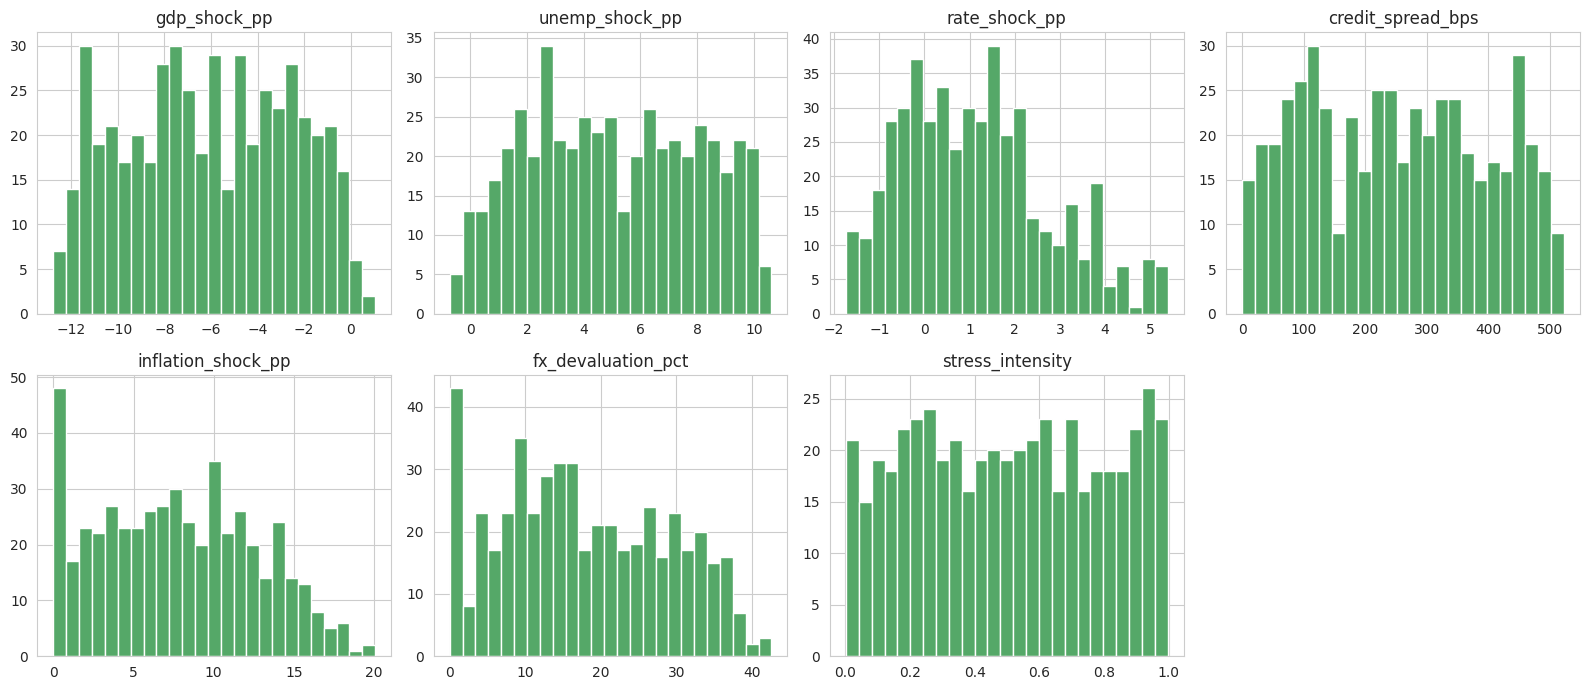

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, shock_cols):
    macro[col].dropna().hist(ax=ax, bins=25, color='#55A868')
    ax.set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Conclusion.** `gdp_shock_pp` is mostly negative, which makes sense since it represents a shock to growth. `rate_shock_pp` and `inflation_shock_pp` are centred closer to zero with a wider spread. None of the shock variables look obviously broken, there are no impossible values like a negative `credit_spread_bps` or an `fx_devaluation_pct` in the thousands.

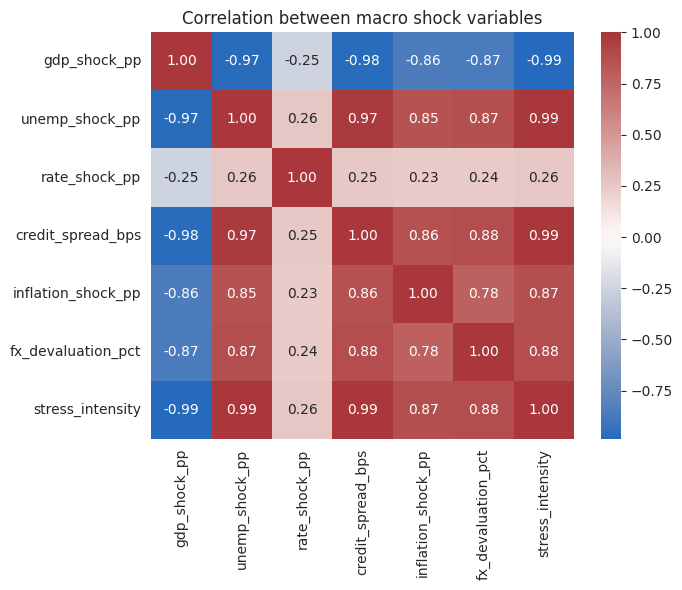

In [15]:
corr = macro[shock_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlation between macro shock variables')
plt.tight_layout()
plt.show()

**Conclusion.** `stress_intensity` correlates fairly strongly with most of the shock columns, which is expected since it looks like a summary measure of how hard a scenario hits the economy overall. `gdp_shock_pp` and `unemp_shock_pp` move in opposite directions, which also lines up with how a recession normally behaves: growth falls while unemployment rises.

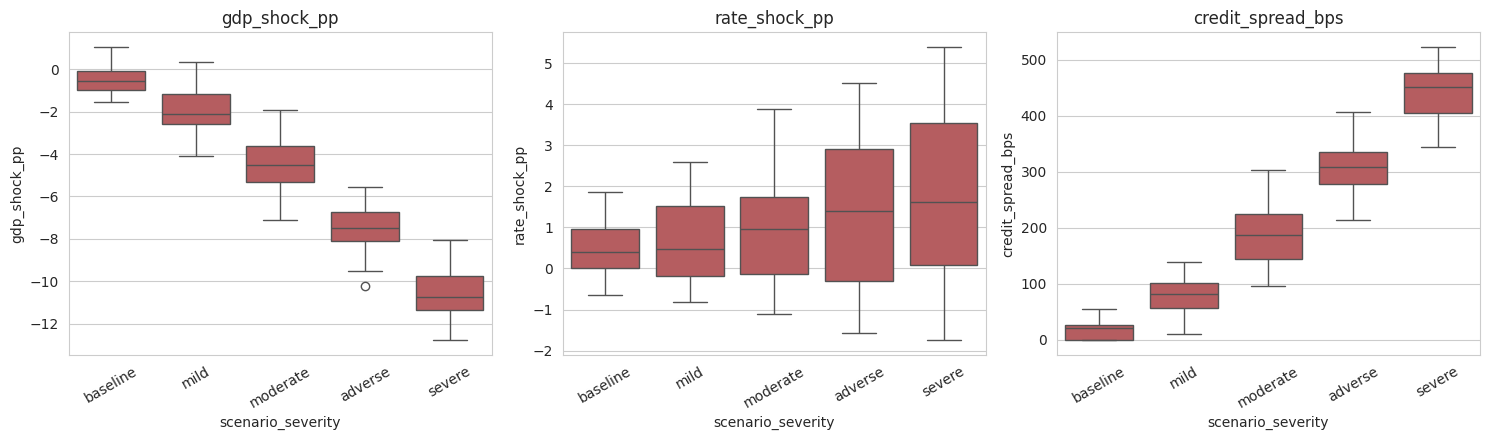

In [16]:
plot_df = macro.dropna(subset=['scenario_severity'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['gdp_shock_pp', 'rate_shock_pp', 'credit_spread_bps']):
    sns.boxplot(data=plot_df, x='scenario_severity', y=col, order=order, ax=ax, color='#C44E52')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Conclusion.** The severity labels behave the way we would want them to. `credit_spread_bps` and `rate_shock_pp` both step up as we move from baseline to severe, and `gdp_shock_pp` gets more negative in the same direction. This is a good sign that the severity label was assigned consistently before the mess was injected into it, so cleaning it back to five categories was the right call rather than treating it as noise.

## 4. Load, clean and explore `macro_stress_scenarios.csv`

This file is at a different level of detail than `macro_scenarios.csv`. Each row here is a scenario and sector combination, with a `pd_multiplier` and an LGD figure per sector, rather than one row per scenario.

In [17]:
raw_stress = pd.read_csv('macro_stress_scenarios.csv', dtype=str, keep_default_na=False)
print('shape:', raw_stress.shape)
raw_stress.head(10)

shape: (60, 11)


,scenario,sector,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,inflation_shock_pp,fx_devaluation_pct,pd_multiplier,base_lgd,stressed_lgd
0,baseline,Technology,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.5
1,baseline,Healthcare,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.35,0.35
2,baseline,Real_Estate,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.35,0.35
3,baseline,Energy,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.45,0.45
4,baseline,Industrials,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.4,0.4
5,baseline,Retial,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.45,0.45
6,baseline,Tele Com,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.5
7,baseline,Consumer,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.45,0.45
8,baseline,Utility,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.3,0.3
9,baseline,Finance,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.4,0.4


In [18]:
print('Unique scenario labels:')
print(sorted(raw_stress['scenario'].unique()))
print()
print('Unique sector labels:')
print(sorted(raw_stress['sector'].unique()))

Unique scenario labels:
['ADVERSE', 'GFC_LIKE', 'Mild', 'adverse', 'adverse ', 'baseline', 'baseline ', 'covid_like', 'covid_like ', 'gfc_like', 'gfc_like ', 'mild', 'severe']

Unique sector labels:
['Consumer', 'Consumer Goods', 'Energy', 'Finance', 'Financial', 'Financials', 'Health Care', 'Healthcare', 'Industrial', 'Industrials', 'Real_Estate', 'Retail', 'Retial', 'Tech', 'Technology', 'Tele Com', 'Telecom', 'Utilities', 'Utility']




First, `scenario` mixes two different ideas: the five severity levels we already cleaned above (`baseline`, `mild`, `adverse`, `severe`, no `moderate` row in this file), plus two named historical scenarios, `gfc_like` and `covid_like`, that do not exist anywhere in `macro_scenarios.csv`. We keep both kinds of labels, just cleaned up, and note the mismatch again later when we try to relate this file to `bank_condition`.

Second, `sector` has the same 10 underlying sectors as the rest of the project (`Technology`, `Healthcare`, `Real_Estate`, `Energy`, `Industrials`, `Retail`, `Telecom`, `Consumer`, `Utilities`, `Financials`), just written inconsistently, for example `Tech`, `Health Care`, `Real Estate`, `Tele Com`, `Financial`, `Finance`, `Retial`, `Industrial`, `Utility`, `Consumer Goods`.

In [19]:
stress = raw_stress.copy()

stress['scenario'] = stress['scenario'].str.strip().str.lower()

SECTOR_MAP = {
    'technology': 'Technology', 'tech': 'Technology',
    'healthcare': 'Healthcare', 'health care': 'Healthcare',
    'real_estate': 'Real_Estate', 'real estate': 'Real_Estate', 'realestate': 'Real_Estate',
    'energy': 'Energy',
    'industrials': 'Industrials', 'industrial': 'Industrials',
    'retail': 'Retail', 'retial': 'Retail',
    'telecom': 'Telecom', 'tele com': 'Telecom',
    'consumer': 'Consumer', 'consumer goods': 'Consumer',
    'utilities': 'Utilities', 'utility': 'Utilities',
    'financials': 'Financials', 'financial': 'Financials', 'finance': 'Financials',
}

stress['sector'] = stress['sector'].str.strip().str.lower().map(SECTOR_MAP)

print('Any sector left unmapped:', stress['sector'].isna().sum())
print(stress['sector'].value_counts())

Any sector left unmapped: 0
sector
Technology     6
Healthcare     6
Real_Estate    6
Energy         6
Industrials    6
Retail         6
Telecom        6
Consumer       6
Utilities      6
Financials     6
Name: count, dtype: int64


In [20]:
stress['pd_multiplier'] = stress['pd_multiplier'].apply(parse_numeric)
for col in ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
            'inflation_shock_pp', 'fx_devaluation_pct', 'base_lgd', 'stressed_lgd']:
    stress[col] = pd.to_numeric(stress[col], errors='coerce')

print('Missing values per column after cleaning:')
print(stress.isna().sum())
print()
print('Fully duplicated rows:', stress.duplicated().sum())

Missing values per column after cleaning:
scenario              0
sector                0
gdp_shock_pp          0
unemp_shock_pp        0
rate_shock_pp         0
credit_spread_bps     0
inflation_shock_pp    0
fx_devaluation_pct    0
pd_multiplier         5
base_lgd              0
stressed_lgd          0
dtype: int64

Fully duplicated rows: 0


**Conclusion, step 4.** `sector` cleaned up to exactly the 10 expected categories with nothing left unmapped, `scenario` is now lower case and whitespace free, and `pd_multiplier` is numeric. There were no duplicate rows in this file. The one thing we cannot fully fix here is the mismatch between `scenario` labels in this file and the severity levels used elsewhere, since `gfc_like` and `covid_like` are simply not part of that scheme.

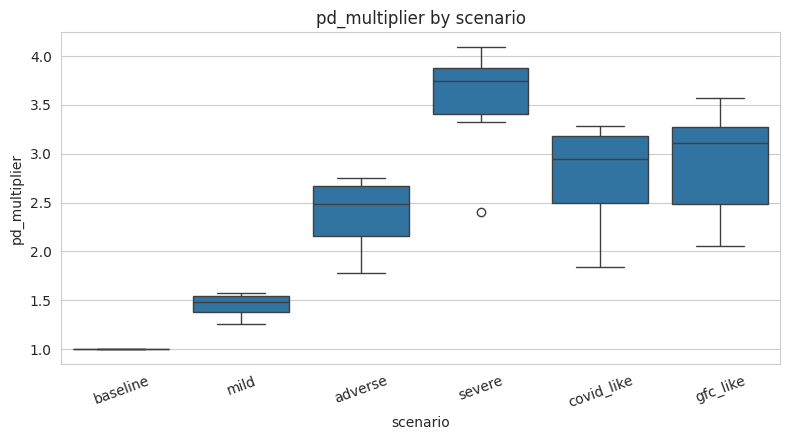

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=stress, x='scenario', y='pd_multiplier',
            order=['baseline', 'mild', 'adverse', 'severe', 'covid_like', 'gfc_like'], ax=ax)
ax.set_title('pd_multiplier by scenario')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

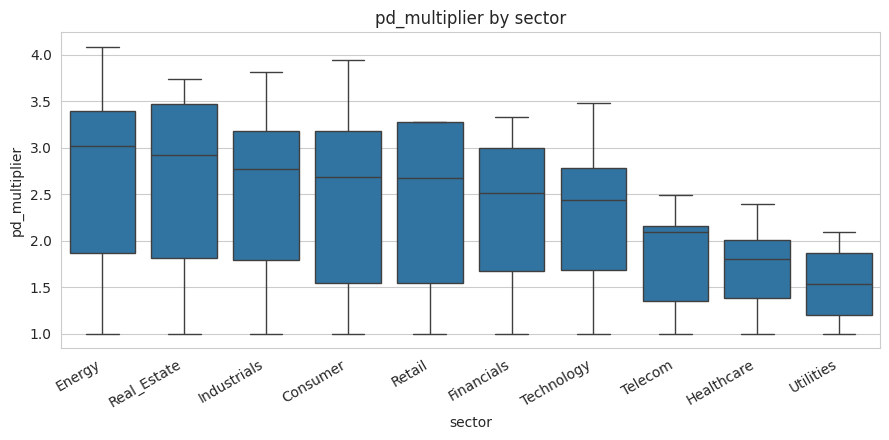

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sector_order = stress.groupby('sector')['pd_multiplier'].mean().sort_values(ascending=False).index
sns.boxplot(data=stress, x='sector', y='pd_multiplier', order=sector_order, ax=ax)
ax.set_title('pd_multiplier by sector')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

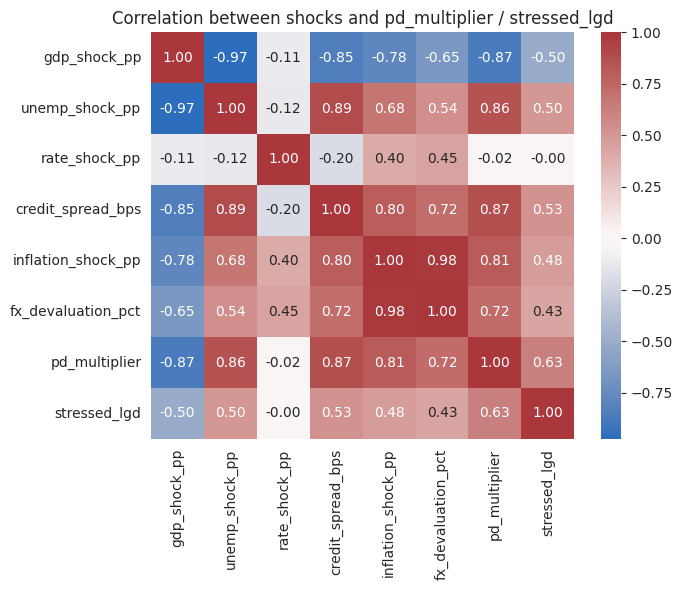

In [23]:
num_cols = ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
            'inflation_shock_pp', 'fx_devaluation_pct', 'pd_multiplier', 'stressed_lgd']
corr2 = stress[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlation between shocks and pd_multiplier / stressed_lgd')
plt.tight_layout()
plt.show()

**Conclusion.** `pd_multiplier` rises sharply for `gfc_like` and `covid_like`, well past the `severe` level, which makes sense since those are meant to represent the worst historical episodes rather than a step on the mild-to-severe scale. Across sectors, the ones you would expect to be more cyclical, such as Energy and Real Estate, tend to sit higher on `pd_multiplier` than steadier sectors like Utilities and Consumer. `credit_spread_bps` and `rate_shock_pp` show the strongest positive relationship with `pd_multiplier` of the shock variables, which is intuitive since both tend to rise together in a credit stress event.

## 5. Load and clean the target label, `bank_condition`

The target label lives in `bank_stress_simulated_panel.csv`, one row per bank and scenario combination. We only need a few columns from it here, `bank_id`, `scenario_id`, `scenario_severity` and `bank_condition`, so we load just those to keep things light.

In [24]:
panel_raw = pd.read_csv(
    'bank_stress_simulated_panel.csv',
    usecols=['bank_id', 'scenario_id', 'scenario_severity', 'bank_condition'],
    dtype=str, keep_default_na=False
)
print('shape:', panel_raw.shape)
print()
print('Unique bank_condition values:')
print(sorted(panel_raw['bank_condition'].unique()))

shape: (20025, 4)

Unique bank_condition values:
[' Stressed', 'CRITICAL', 'Critcal', 'Critical', 'Critical ', 'HEALTHY', 'Healthy', 'Healthy ', 'Helathy', 'STRESSED', 'Stresed', 'Stressed', 'critical', 'healthy', 'stressed']


In [25]:
CONDITION_MAP = {
    'healthy': 'Healthy', 'helathy': 'Healthy',
    'stressed': 'Stressed', 'stresed': 'Stressed',
    'critical': 'Critical', 'critcal': 'Critical',
}

def clean_condition(value):
    v = value.strip().lower()
    return CONDITION_MAP.get(v, np.nan)

panel = panel_raw.copy()
panel['bank_condition'] = panel['bank_condition'].apply(clean_condition)
panel['scenario_severity'] = panel['scenario_severity'].apply(clean_severity)

print('Unmapped bank_condition rows after cleaning:', panel['bank_condition'].isna().sum())
print()

before = len(panel)
panel = panel.drop_duplicates(subset=['bank_id', 'scenario_id'])
after = len(panel)
print(f'Dropped {before - after} duplicate bank_id and scenario_id combinations, {after} rows left')

Unmapped bank_condition rows after cleaning: 0

Dropped 25 duplicate bank_id and scenario_id combinations, 20000 rows left


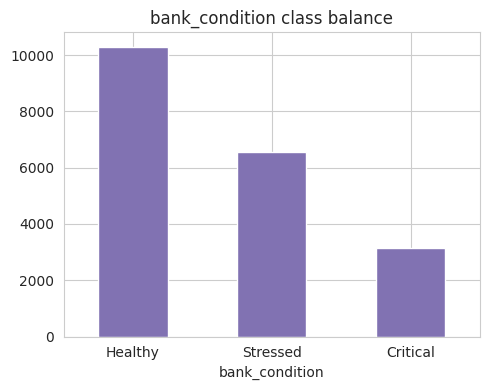

bank_condition
Healthy     10291
Stressed     6557
Critical     3152
Name: count, dtype: int64
bank_condition
Healthy     51.5
Stressed    32.8
Critical    15.8
Name: count, dtype: float64


In [26]:
counts = panel['bank_condition'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color='#8172B2')
ax.set_title('bank_condition class balance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)
print((counts / counts.sum() * 100).round(1))

**Conclusion, step 5.** `bank_condition` cleans down to exactly the three expected classes with no rows left unmapped. The classes are not perfectly balanced, `Healthy` is the largest group, which is worth remembering if this ever becomes a classification target, since a model could get a deceptively high accuracy just by always predicting the majority class.

## 6. Merge `macro_scenarios.csv` with the target label

In [27]:
merged = panel.merge(
    macro.drop(columns=['scenario_severity']),
    on='scenario_id', how='left', indicator=True
)

print('Merge match summary:')
print(merged['_merge'].value_counts())
merged = merged.drop(columns=['_merge'])

Merge match summary:
_merge
both          20000
left_only         0
right_only        0
Name: count, dtype: int64


**Conclusion.** Every row in the panel found a matching scenario in the cleaned `macro_scenarios.csv`, so the two files line up cleanly on `scenario_id` once both sides are cleaned. We now have one row per bank and scenario, carrying both the macro shock values and the bank_condition outcome for that scenario.

## 7. How do the macro shocks relate to `bank_condition`

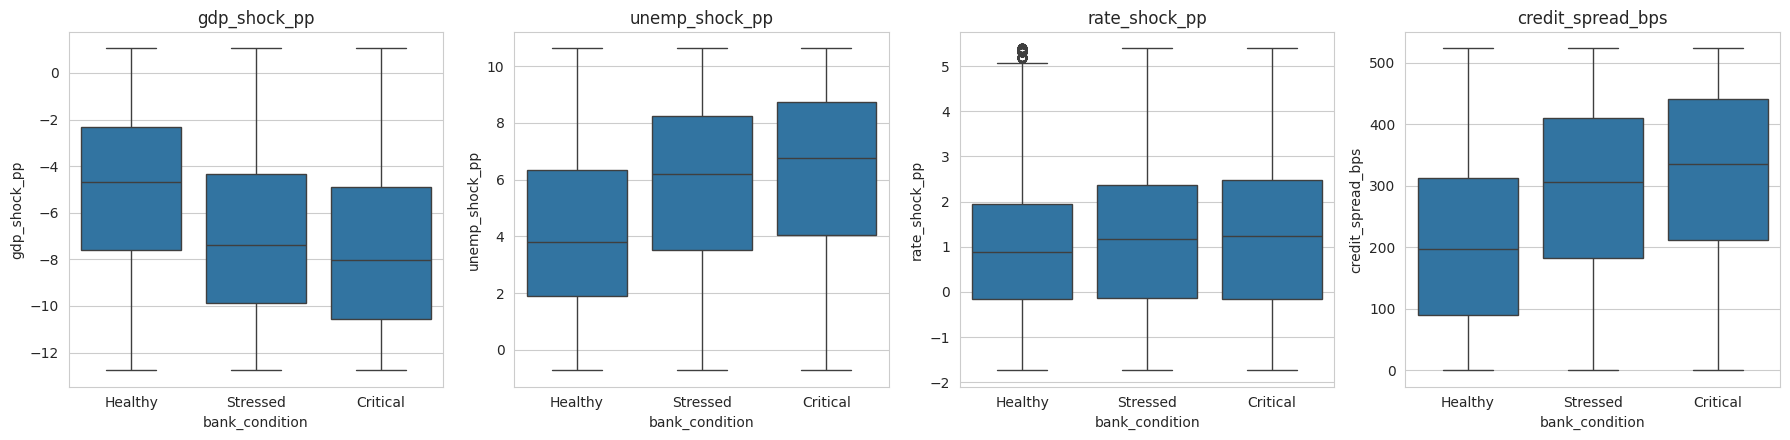

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps']):
    sns.boxplot(data=merged, x='bank_condition', y=col,
                order=['Healthy', 'Stressed', 'Critical'], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [29]:
condition_rank = {'Healthy': 0, 'Stressed': 1, 'Critical': 2}
merged['bank_condition_rank'] = merged['bank_condition'].map(condition_rank)

shock_cols_merge = ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
                    'inflation_shock_pp', 'fx_devaluation_pct', 'stress_intensity']

corr_with_target = merged[shock_cols_merge + ['bank_condition_rank']].corr(method='spearman')['bank_condition_rank'].drop('bank_condition_rank')
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)
print('Spearman correlation of each shock variable with bank_condition (0 = Healthy, 1 = Stressed, 2 = Critical):')
print(corr_with_target)

Spearman correlation of each shock variable with bank_condition (0 = Healthy, 1 = Stressed, 2 = Critical):
stress_intensity      0.305165
credit_spread_bps     0.302698
gdp_shock_pp         -0.302271
unemp_shock_pp        0.301606
fx_devaluation_pct    0.274027
inflation_shock_pp    0.270108
rate_shock_pp         0.057470
Name: bank_condition_rank, dtype: float64


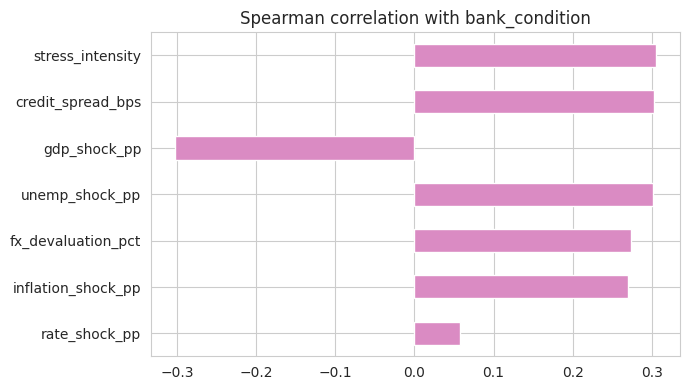

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
corr_with_target.plot(kind='barh', ax=ax, color='#DA8BC3')
ax.set_title('Spearman correlation with bank_condition')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

bank_condition     Healthy  Stressed  Critical
scenario_severity                             
baseline             0.736     0.187     0.078
mild                 0.687     0.224     0.089
moderate             0.605     0.281     0.114
adverse              0.460     0.371     0.169
severe               0.304     0.439     0.257


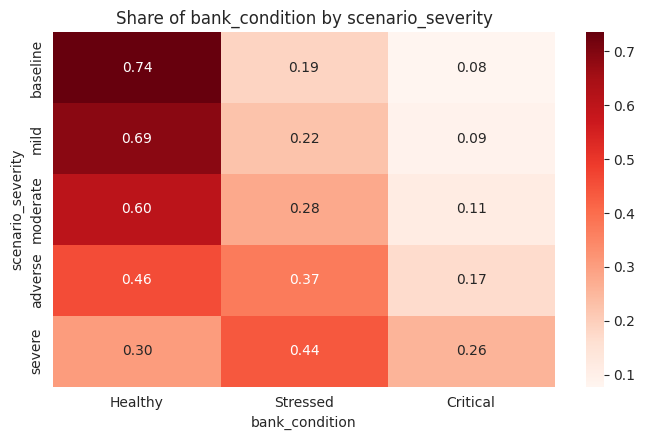

In [31]:
ct = pd.crosstab(merged['scenario_severity_x'] if 'scenario_severity_x' in merged.columns else merged['scenario_severity'],
                  merged['bank_condition'], normalize='index').reindex(order)
ct = ct[['Healthy', 'Stressed', 'Critical']]
print(ct.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Reds', ax=ax)
ax.set_title('Share of bank_condition by scenario_severity')
plt.tight_layout()
plt.show()

**Conclusion.** The shock variables that line up most with worse bank_condition are `credit_spread_bps`, `rate_shock_pp` and `gdp_shock_pp`, which matches how a real credit stress event plays out, wider spreads and a demand shock both eat into capital faster than the other shocks. The crosstab tells the same story from the severity side, the share of `Critical` banks rises steadily as we move from `baseline` scenarios to `severe` ones, and `Healthy` shrinks in the same direction. This is a reassuring consistency check, since it means the severity label and the bank-level outcome agree with each other even though they were cleaned separately.

## 8. Relating `macro_stress_scenarios.csv` to `bank_condition`

This file does not join to the panel on `scenario_id`, since it only has a `scenario` name and a `sector`, not a scenario_id, and no bank_id at all. The best we can do without changing the grain of the data is to compare the average `pd_multiplier` per named scenario against the `Critical` share for the severity levels that exist in both files.

In [32]:
scenario_to_severity = {
    'baseline': 'baseline', 'mild': 'mild', 'adverse': 'adverse', 'severe': 'severe',
}

stress_summary = stress.groupby('scenario')['pd_multiplier'].mean().rename('mean_pd_multiplier')

severity_condition = merged.groupby('scenario_severity')['bank_condition'].apply(
    lambda s: (s == 'Critical').mean()
).rename('critical_share')

comparison = pd.DataFrame(stress_summary).reset_index()
comparison['matching_severity'] = comparison['scenario'].map(scenario_to_severity)
comparison = comparison.merge(severity_condition, left_on='matching_severity', right_index=True, how='left')
comparison

,scenario,mean_pd_multiplier,matching_severity,critical_share
0,adverse,2.376200,adverse,0.169400
1,baseline,1.000000,baseline,0.077885
2,covid_like,2.781333,NaN,NaN
3,gfc_like,2.907889,NaN,NaN
4,mild,1.448200,mild,0.088520
5,severe,3.543429,severe,0.256641


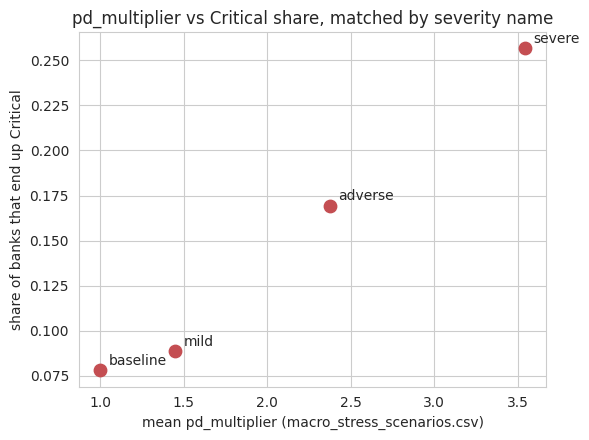

In [33]:
plot_data = comparison.dropna(subset=['critical_share'])
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(plot_data['mean_pd_multiplier'], plot_data['critical_share'], s=80, color='#C44E52')
for _, row in plot_data.iterrows():
    ax.annotate(row['scenario'], (row['mean_pd_multiplier'], row['critical_share']),
                textcoords='offset points', xytext=(6, 4))
ax.set_xlabel('mean pd_multiplier (macro_stress_scenarios.csv)')
ax.set_ylabel('share of banks that end up Critical')
ax.set_title('pd_multiplier vs Critical share, matched by severity name')
plt.tight_layout()
plt.show()

**Conclusion.** For the four severity levels that exist in both files, a higher average `pd_multiplier` in `macro_stress_scenarios.csv` does line up with a higher share of banks ending up `Critical`. `gfc_like` and `covid_like` have no matching row in this comparison and simply cannot be validated against `bank_condition` with the data we have, since the panel was never simulated for those two named scenarios. That gap is worth flagging to whoever owns the data generation step, rather than trying to guess a mapping.

## 9. Summary

- `macro_scenarios.csv`: standardised `scenario_severity` to five categories, stripped the `bps` suffix from `credit_spread_bps`, converted `rate_shock_pp` to numeric, and removed 4 duplicate rows. Rows with an unreadable severity label were kept and marked as missing rather than dropped, since the numeric shock values in those rows are still usable.
- `macro_stress_scenarios.csv`: standardised `sector` to 10 categories and `scenario` to lower case, and converted `pd_multiplier` to numeric. No duplicate rows were found.
- `bank_stress_simulated_panel.csv`: standardised `bank_condition` to three categories and `scenario_severity` using the same mapping as above, and dropped duplicate bank and scenario combinations.

Now after cleaning:

- The severity labels behave sensibly, shocks get larger and `bank_condition` gets worse as we move from baseline to severe.
- `credit_spread_bps`, `rate_shock_pp` and `gdp_shock_pp` are the shock variables most associated with a bank ending up `Stressed` or `Critical`.
- `macro_stress_scenarios.csv` broadly agrees with this, but two of its named scenarios, `gfc_like` and `covid_like`, fall outside the severity scheme used everywhere else in the project and cannot currently be checked against `bank_condition`.

Now we'll need to decide how to handle the rows with an unrecoverable `scenario_severity` before any modelling we can either drop them or keep them as an explicit "unknown" category, and consider whether `gfc_like` and `covid_like` should be simulated through the same panel-generation process so they can be judged on the same basis as the other five scenarios.